### Importing the dependencies

In [1]:
# Import basic modules
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import random

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier    #RandomForestRegressor

from sklearn.metrics import roc_curve, auc, plot_confusion_matrix, classification_report , accuracy_score, confusion_matrix
 #plot_cofusion_matrix
    
import warnings
warnings.filterwarnings('ignore')

In [2]:
cancer = pd.read_csv('healthcare_data.csv')
pd.set_option('display.max_columns', 50)   #to make sure all columns get displayed
cancer.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


#### Analysis:
1. Diagnosis tells about the type of cancer as B or M ('Benign', 'Malignant')
2. Type of cancer is based on the rest of the variables hence "Diagnosis" is the output variable (y)
3. Encoding of Diagnosis variable needs to be done
4. All other variables are in numerical form, hence no encoding is needed.
5. Since it is a Random Forest model, feature scaling is NOT necessary here. It is not distance based model.
6. The last column Unnamed is completely empty so it can be removed.


In [3]:
cancer.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [4]:
# classes = ['Benign', 'Malignant']cancer.shape
cancer.shape

(569, 33)

In [5]:
# Encoding of output variable
cancer['diagnosis'] = cancer['diagnosis'].map({'B':0 , 'M':1})

In [6]:
#Since the last column does not make sense, lets remove it!

cancer = cancer.drop(['id','Unnamed: 32'], axis = 1)
cancer.head(2)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902


In [7]:
cancer.shape

(569, 31)

In [8]:
#Assigning independent and dependent variables:

feature_space = cancer.iloc[:, cancer.columns != 'diagnosis']   #x
feature_class = cancer.iloc[:, cancer.columns == 'diagnosis']   #y


x_train, x_test, y_train, y_test = train_test_split(feature_space,
                                                                    feature_class,
                                                                    test_size = 0.20, 
                                                                    random_state = 42)

In [9]:
x_test.shape[0]

114

In [10]:
# Set the random state for reproducibility
fit_rf = RandomForestClassifier(random_state=30)

#use random_state for instantiating any classification algorithm

#### Hypertuning of parameters

In [11]:
# type(x_train)

In [12]:
y_train

,diagnosis
68,0
181,1
63,0
248,0
60,0
...,...
71,0
106,0
270,0
435,1


In [13]:
type(y_train)

pandas.core.frame.DataFrame

In [14]:
y_train = y_train['diagnosis']

In [15]:
type(y_train)

pandas.core.series.Series

#### GridSearchCV allows to select correct set of hyperparameter values. This step takes time.

In [16]:
# Providing the different values of hyperparameters
#Creating a dictionary such that we have key value pair of each hyperparameter
#Key denotes the "hyperparameter name" & value denotes the list of values we want to try for it

# Log to the base 10
# log to the base n (natural log)

# random forest & decision tree the log used it specifically to the base2
# maximum features = log[to the base 2](numer of features)

param_dist = {'max_depth': [2, 3, 4, 8],
              'max_features': ['auto', 'sqrt', 'log2', None],   #log of n to the base 2
                'bootstrap' : [True, False],
              'criterion': ['gini', 'entropy']}

# Running gridsearchCV to check for all the different PnCs of these parameter values
cv_rf = GridSearchCV(fit_rf, cv = 10,
                     param_grid=param_dist, verbose = 0,
                     n_jobs = 3)


#Fitting the train set , so that grid search is executed on this dataset
cv_rf.fit(x_train, y_train)

#Main dataset: select small datasets from that, this is called bootstrapping

GridSearchCV(cv=10, estimator=RandomForestClassifier(random_state=30), n_jobs=3,
             param_grid={'bootstrap': [True, False],
                         'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 3, 4, 8],
                         'max_features': ['auto', 'sqrt', 'log2', None]})

In [17]:
#Printing the best parameters by using best_params
print('Best Parameters using grid search: \n', cv_rf.best_params_)  #to get best Hyperparameters

Best Parameters using grid search: 
 {'bootstrap': False, 'criterion': 'entropy', 'max_depth': 8, 'max_features': 'log2'}


In [18]:
#Finally the best parameters are specified

fit_rf.set_params(criterion = 'entropy',
                  max_features = 'sqrt', 
                  bootstrap = True,
                  max_depth = 8)

RandomForestClassifier(criterion='entropy', max_depth=8, max_features='sqrt',
                       random_state=30)

In [19]:
fit_rf.fit(x_train, y_train)
y_pred = fit_rf.predict(x_test)

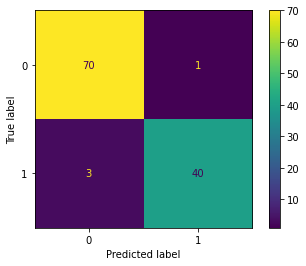

In [20]:
plot_confusion_matrix(fit_rf, x_test, y_test)

In [21]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [22]:
predictions_prob = fit_rf.predict_proba(x_test)[:, 1]

fpr, tpr, threshold = roc_curve(y_test,predictions_prob)
auc(fpr,tpr)

0.9967245332459875

#### To check how Cross Validation worked internally

In [23]:
# # #  To crossvalidate the dataset
# from sklearn.model_selection import cross_val_score

# scores = cross_val_score(fit_rf, x_train, y_train, cv=10)
# scores

In [24]:
# scores.mean()

#### Feature Importance

In [36]:
importances = fit_rf.feature_importances_
importances

array([0.03065758, 0.02030815, 0.01750405, 0.04284829, 0.00745998,
       0.01958391, 0.06346169, 0.09485573, 0.00481976, 0.00368959,
       0.01623802, 0.00719237, 0.01070385, 0.03666736, 0.00487728,
       0.00557527, 0.0101423 , 0.00590461, 0.00829159, 0.00743924,
       0.07225237, 0.03374657, 0.12725913, 0.13522046, 0.01789806,
       0.01759217, 0.02549488, 0.13460661, 0.01138343, 0.00632569])

In [34]:
importances = fit_rf.feature_importances_
fi= pd.DataFrame()
fi['Features']= x_train.columns
fi['Importance_score']=importances
fi.sort_values('Importance_score', ascending = False)

,Features,Importance_score
23,area_worst,0.135220
27,concave points_worst,0.134607
22,perimeter_worst,0.127259
7,concave points_mean,0.094856
20,radius_worst,0.072252
6,concavity_mean,0.063462
3,area_mean,0.042848
13,area_se,0.036667
21,texture_worst,0.033747
0,radius_mean,0.030658
